In [88]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from odin import PostgresWrapper



In [2]:
coredb = PostgresWrapper(
    host=os.getenv("ROCKYDB_HOST"),
    db_name="core",
    user=os.getenv("ROCKYDB_USR"),
    password=os.getenv("ROCKYDB_PWD"),
    google_creds_path=os.getenv("GCLOUD_CREDS_PATH")
)

In [3]:
coredb.test_connection()

Connected to 'core' via 34.106.196.176:5432


True

In [4]:
date_since = '2026-01-01'

datafiles = coredb.query(
    """
        SELECT * FROM datafile
        WHERE date_created >= %s
    """,
    [date_since]
)

print(f"{len(datafiles)} datafiles created since {date_since}")

57526 datafiles created since 2026-01-01


In [ ]:
datafile_df = pd.DataFrame(datafiles)

datafile_df = datafile_df[[
    'id',
    'task_id',
    'status',
    'date_card_created',
    'flex_processing',
    'ftp_directory',
    'ftp_file_name',
    'date_ftp_file_date',
    'file_type',
    'date_created',
    'date_modified',
    'data_card_id',
    'archived',
]]

In [51]:
# turn rows into dataframe
datafile_df = pd.DataFrame(datafiles)

# narrow columns
datafile_df = datafile_df[[
    'id',
    'task_id',
    'status',
    'date_card_created',
    'flex_processing',
    'ftp_directory',
    'ftp_file_name',
    'date_ftp_file_date',
    'file_type',
    'date_created',
    'date_modified',
    'data_card_id',
    'archived',
]]

# sort dataframe
datafile_df = datafile_df.sort_values("date_created").reset_index()

# add "day of week" column to dataframe
datafile_df['day_of_week'] = datafile_df['date_created'].apply(lambda x: x.strftime("%A"))

# lets find the very first "Sunday"
first_sunday = datafile_df[datafile_df['day_of_week'] == "Sunday"].sort_values("date_created").iloc[0]

# and the last "Saturday"
last_saturday = datafile_df[datafile_df['day_of_week'] == "Saturday"].sort_values("date_created").iloc[-1]

# narrow dataframe to only include rows between these two days
datafile_df = datafile_df.loc[first_sunday.name:last_saturday.name]


In [72]:
len(datafile_df)

55256

In [53]:
day_counts = datafile_df['day_of_week'].value_counts()
print(day_counts)

least_busy_day = day_counts.idxmin()
print(f"\nLeast busy day: {least_busy_day} ({day_counts.min()} entries)")

day_of_week
Tuesday      14594
Friday       10433
Wednesday    10065
Thursday      9734
Monday        8960
Saturday       957
Sunday         513
Name: count, dtype: int64

Least busy day: Sunday (513 entries)


In [54]:
# extract hour, then bucket into 2-hour blocks
datafile_df['hour'] = datafile_df['date_created'].apply(lambda x: x.hour)
datafile_df['two_hour_block'] = (datafile_df['hour'] // 2) * 2

# label like "00:00-02:00"
datafile_df['two_hour_label'] = datafile_df['two_hour_block'].apply(
    lambda h: f"{h:02d}:00-{h+2:02d}:00"
)

block_counts = datafile_df['two_hour_label'].value_counts().reindex(
    [f"{h:02d}:00-{h+2:02d}:00" for h in range(0, 24, 2)], fill_value=0
)
print(block_counts)

least_busy_block = block_counts.idxmin()
print(f"\nLeast busy 2-hour period: {least_busy_block} ({block_counts.min()} entries)")

two_hour_label
00:00-02:00     1437
02:00-04:00      658
04:00-06:00     1051
06:00-08:00     4274
08:00-10:00    13011
10:00-12:00     4265
12:00-14:00     4893
14:00-16:00     7519
16:00-18:00     6461
18:00-20:00     6011
20:00-22:00     3424
22:00-24:00     2252
Name: count, dtype: int64

Least busy 2-hour period: 02:00-04:00 (658 entries)


In [55]:
# extract the actual calendar date (not datetime) so we can count unique days
datafile_df['date_only'] = datafile_df['date_created'].apply(lambda x: x.date())

# how many distinct calendar dates fall on each weekday in your range?
day_occurrences = (
    datafile_df[['date_only', 'day_of_week']]
    .drop_duplicates()
    ['day_of_week']
    .value_counts()
)

day_totals = datafile_df['day_of_week'].value_counts()

day_avg = (day_totals / day_occurrences).reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
print(day_avg.sort_values())

day_of_week
Sunday        16.548387
Saturday      30.870968
Monday       289.032258
Thursday     314.000000
Wednesday    324.677419
Friday       336.548387
Tuesday      470.774194
Name: count, dtype: float64


In [65]:
# make sure these exist (from earlier steps)
datafile_df['date_only'] = datafile_df['date_created'].apply(lambda x: x.date())
datafile_df['hour'] = datafile_df['date_created'].apply(lambda x: x.hour)
datafile_df['two_hour_block'] = (datafile_df['hour'] // 2) * 2
datafile_df['two_hour_label'] = datafile_df['two_hour_block'].apply(
    lambda h: f"{h:02d}:00-{h+2:02d}:00"
)

all_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
all_blocks = [f"{h:02d}:00-{h+2:02d}:00" for h in range(0, 24, 2)]

# how many distinct calendar dates fall on each weekday (needed to normalize)
day_occurrences = (
    datafile_df[['date_only', 'day_of_week']]
    .drop_duplicates()
    .groupby('day_of_week')
    .size()
    .reindex(all_days, fill_value=0)
)

# raw counts per (day_of_week, two_hour_block)
raw_counts = (
    datafile_df
    .groupby(['day_of_week', 'two_hour_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=all_days, columns=all_blocks, fill_value=0)
)

# normalize each row by how many times that weekday occurred in the range
avg_traffic = raw_counts.div(day_occurrences, axis=0)

print("Average entries per 2-hour block, by day of week:")
print(avg_traffic.round(2))

# quietest 2-hour block for each day
quietest_block_per_day = avg_traffic.idxmin(axis=1)
quietest_block_value = avg_traffic.min(axis=1)

summary = pd.DataFrame({
    'day_avg': day_avg,  # from earlier
    'quietest_block': quietest_block_per_day,
    'quietest_block_avg': quietest_block_value.round(2),
})
print("\nSummary:")
print(summary)
display(summary)

Average entries per 2-hour block, by day of week:
two_hour_label  00:00-02:00  02:00-04:00  04:00-06:00  06:00-08:00  \
day_of_week                                                          
Monday                 0.84         0.29         6.26        22.94   
Tuesday               10.23         2.84         7.13        48.48   
Wednesday              8.77         6.77         4.35        18.10   
Thursday               8.65         5.45         3.87        26.10   
Friday                 7.87         4.32         7.61        19.97   
Saturday               8.84         1.45         4.55         1.94   
Sunday                 1.16         0.10         0.13         0.35   

two_hour_label  08:00-10:00  10:00-12:00  12:00-14:00  14:00-16:00  \
day_of_week                                                          
Monday                69.13        36.16        28.77        33.35   
Tuesday              169.13        36.19        17.19        42.52   
Wednesday             66.52        23.7

,day_avg,quietest_block,quietest_block_avg
day_of_week,,,
Monday,289.032258,02:00-04:00,0.29
Tuesday,470.774194,02:00-04:00,2.84
Wednesday,324.677419,04:00-06:00,4.35
Thursday,314.000000,04:00-06:00,3.87
Friday,336.548387,02:00-04:00,4.32
Saturday,30.870968,22:00-24:00,0.16
Sunday,16.548387,02:00-04:00,0.10


In [66]:

display(avg_traffic.round(2))


two_hour_label,00:00-02:00,02:00-04:00,04:00-06:00,06:00-08:00,08:00-10:00,10:00-12:00,12:00-14:00,14:00-16:00,16:00-18:00,18:00-20:00,20:00-22:00,22:00-24:00
day_of_week,,,,,,,,,,,,
Monday,0.84,0.29,6.26,22.94,69.13,36.16,28.77,33.35,28.58,31.97,16.23,14.52
Tuesday,10.23,2.84,7.13,48.48,169.13,36.19,17.19,42.52,51.74,49.39,24.35,11.58
Wednesday,8.77,6.77,4.35,18.10,66.52,23.71,27.39,41.45,42.32,39.52,28.52,17.26
Thursday,8.65,5.45,3.87,26.10,63.74,15.06,34.81,49.10,39.23,31.19,20.52,16.29
Friday,7.87,4.32,7.61,19.97,40.52,25.29,43.10,71.84,45.52,38.26,19.87,12.39
Saturday,8.84,1.45,4.55,1.94,4.19,0.39,4.03,3.94,0.58,0.42,0.39,0.16
Sunday,1.16,0.10,0.13,0.35,6.48,0.77,2.55,0.35,0.45,3.16,0.58,0.45


In [69]:
avg_traffic.round(2).to_csv("2hr_avg.csv")

In [71]:
summary.to_csv("quietest_block.csv")

In [83]:
times = []

for day, time_blocks in avg_traffic.iterrows():
    for c in avg_traffic.columns:

        times.append({
            "day": day,
            "time": c,
            "avg_files": time_blocks[c]
        })


In [86]:
times

[{'day': 'Monday',
  'time': '00:00-02:00',
  'avg_files': np.float64(0.8387096774193549)},
 {'day': 'Monday',
  'time': '02:00-04:00',
  'avg_files': np.float64(0.2903225806451613)},
 {'day': 'Monday',
  'time': '04:00-06:00',
  'avg_files': np.float64(6.258064516129032)},
 {'day': 'Monday',
  'time': '06:00-08:00',
  'avg_files': np.float64(22.93548387096774)},
 {'day': 'Monday',
  'time': '08:00-10:00',
  'avg_files': np.float64(69.12903225806451)},
 {'day': 'Monday',
  'time': '10:00-12:00',
  'avg_files': np.float64(36.16129032258065)},
 {'day': 'Monday',
  'time': '12:00-14:00',
  'avg_files': np.float64(28.774193548387096)},
 {'day': 'Monday',
  'time': '14:00-16:00',
  'avg_files': np.float64(33.354838709677416)},
 {'day': 'Monday',
  'time': '16:00-18:00',
  'avg_files': np.float64(28.580645161290324)},
 {'day': 'Monday',
  'time': '18:00-20:00',
  'avg_files': np.float64(31.967741935483872)},
 {'day': 'Monday',
  'time': '20:00-22:00',
  'avg_files': np.float64(16.22580645161

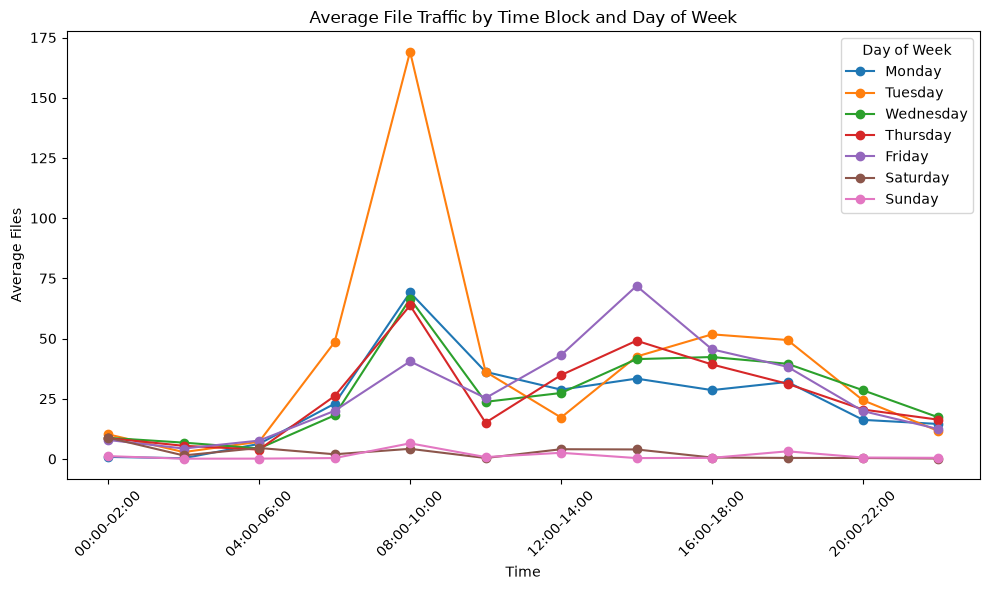

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# example data
# data = [
#     {"day_of_week": "Monday", "time": "00:00-02:00", "avg_files": 5.2},
#     {"day_of_week": "Monday", "time": "02:00-04:00", "avg_files": 3.1},
#     # ... etc
# ]

df = pd.DataFrame(times)

# pivot so each day_of_week becomes its own column, indexed by time
pivot_df = df.pivot(index="time", columns="day", values="avg_files")

# make sure time blocks appear in chronological order, not alphabetical
time_order = sorted(pivot_df.index, key=lambda t: int(t.split(":")[0]))
pivot_df = pivot_df.reindex(time_order)

# optional: order the legend/lines Mon-Sun instead of alphabetically
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_df = pivot_df[[d for d in day_order if d in pivot_df.columns]]

# plot
pivot_df.plot(figsize=(10, 6), marker='o')
plt.xlabel("Time")
plt.ylabel("Average Files")
plt.title("Average File Traffic by Time Block and Day of Week")
plt.xticks(rotation=45)
plt.legend(title="Day of Week")
plt.tight_layout()
plt.show()

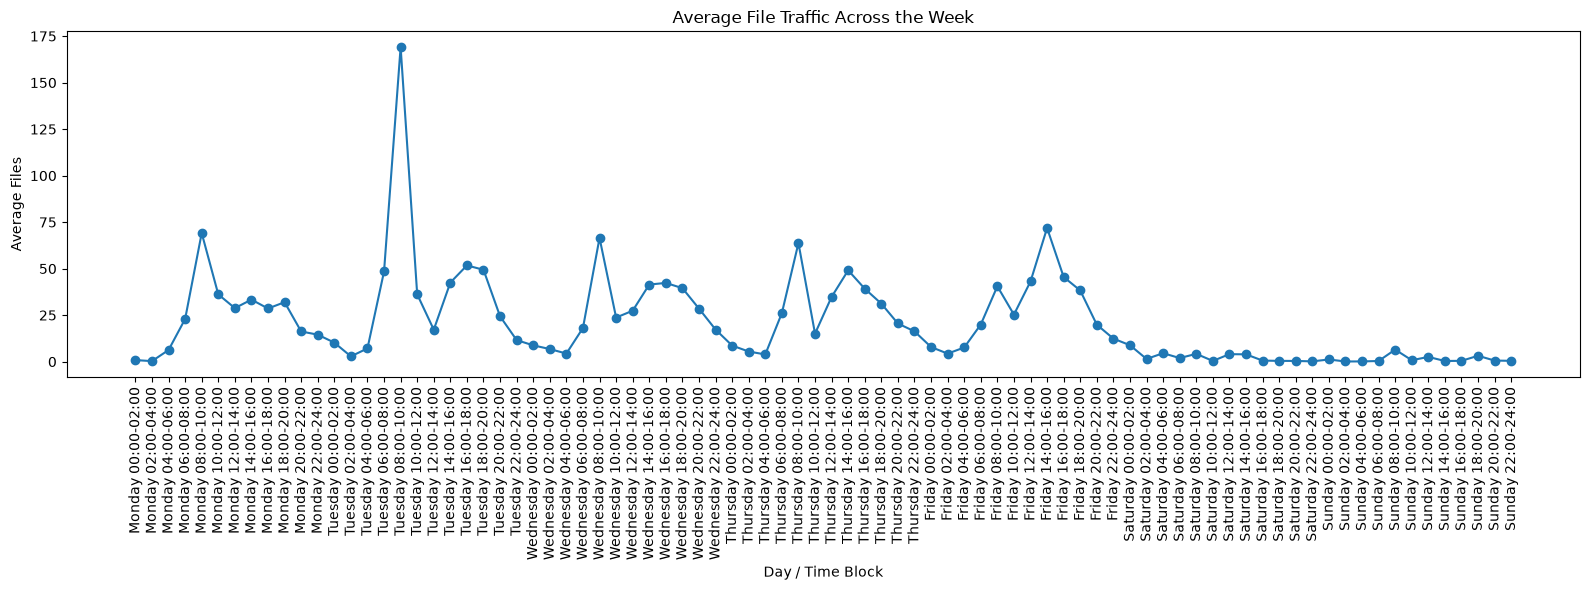

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# data = [
#     {"day_of_week": "Monday", "time": "00:00-02:00", "avg_files": 5.2},
#     {"day_of_week": "Monday", "time": "02:00-04:00", "avg_files": 3.1},
#     # ... etc
# ]

df = pd.DataFrame(times)

# define chronological orderings
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
time_order = sorted(df['time'].unique(), key=lambda t: int(t.split(":")[0]))

# make day_of_week and time categorical so sort_values respects the orders above
df['day_of_week'] = pd.Categorical(df['day'], categories=day_order, ordered=True)
df['time'] = pd.Categorical(df['time'], categories=time_order, ordered=True)

df = df.sort_values(['day_of_week', 'time']).reset_index(drop=True)

# combined label for the x-axis
df['label'] = df['day_of_week'].astype(str) + " " + df['time'].astype(str)

# plot
plt.figure(figsize=(16, 6))
plt.plot(df['label'], df['avg_files'], marker='o')
plt.xlabel("Day / Time Block")
plt.ylabel("Average Files")
plt.title("Average File Traffic Across the Week")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()